# Assignment 2 — Enzyme-Activity-Constrained Metabolic Modeling of *E. coli*

**Course:** KEN3170 – Multi-scale Modelling of Biological Systems (Week 2, Metabolic Modeling)


### Exercise 1a — Are linear-pathway maximal activities equal to each other?

**No**

- **What mass balance means:** in steady state, whatever enters a linear pathway must leave it. If the chain is a simple path (no branching), every reaction in that chain carries exactly the same flux.

- **Maximal reaction activities are independent measurements** of each enzyme's capacity (how much enyzme is available). They are not connected to mass balance. The upper limit of their reaction capacity is measured. Two enzymes in the same pathway can be expressed at different levels, meaning their maximal activities are not dependent on each other.

This is indicated by the arrows on the ESCHER maps showing us different colours.


### Exercise 1b — What do the grey arrows at the lower end of the map show?

The colour of a reaction on the ESCHER map is giving a visual indication of measured activity, with the legend showing what each colour means. There is no grey on this legend.

What grey can mean on the ESCHER visualization:

1. No measurement at all, the reaction is not listed on `e_coli_core_expression.csv`, hovering over the grey reaction arrow shows us "data: no data".

2. A measured value of exactly 0.
   There are reactions in the .csv that have an activation of 0 mmol/gDW/h (for example `PFL`, `ACALD`, `AKGt2r`, `ALCD2x`, `D_LACt2`, …). The zero is our measured, reported number. That means that the enzymes capacity is actually 0, which ESCHER displays as a grey arrow, similar to missing data. The way to differentiate between them is by hovering over the reaction.

The two cases look the same, but they can be identified and mean different things.

| What we see | What it means |
|---|---|
| Grey arrow for "data: no data" | No measurement available (unknown capacity) |
| Grey arrow for a reaction with "data: 0" | Measured to be zero |

Biologically, the difference is meaningful. An unmeasured enzyme activity tells us nothing about the enzyme or it's role in the metabolism, while a measured capacity of zero is telling us that the enzyme cannot carry flux within the constraints of the systems. Unfortunately, the ESCHER map requires us to check the difference ourselves.


---
## Exercise 2 — Building the enzyme-activity-constrained model

Before running FBA, implementation of the measured maximal activities as flux bounds:

1. For a reversible reaction: set `lower = -value`, `upper = +value`.
2. For an irreversible reaction: only set `upper = +value`; leave the minimum at 0.
3. Reactions with no data: keep their default constraints.
4. The glucose exchange `EX_glc__D_e`: remove its pre-existing bound and use a high absolute
   default instead (so it does not limit growth in Exercise 3a).
5. The ATP-maintenance reaction `ATPM`: leave the lower flux as-is (it represents cellular energy
   demand, not an enzyme capacity).

Below is a printed table of every reaction's final lower/upper bound.


In [7]:
import csv
import cobra
from cobra.io import load_model

model = load_model('textbook')  # unexpected errors when loading e_coli_core.json so this is fix

filename = 'e_coli_core_expression.csv'
activity_data = {}

with open(filename, mode='r', newline='') as file:
    reader = csv.reader(file)
    for row in reader:
        if not row or row[0].startswith('#'):
            continue
        reaction_id = row[0].strip()
        value = float(row[1])
        activity_data[reaction_id] = value

for reaction in model.reactions:

    if reaction.id in activity_data:
        value = activity_data[reaction.id]

        if reaction.reversibility:
            reaction.lower_bound = -value
            reaction.upper_bound = value
        else:
            reaction.lower_bound = 0
            reaction.upper_bound = value

# for glucose exchange reaction we remove its pre-existing maximal absolute flux bound and use the high absolute default bound instead
glc_exchange = model.reactions.get_by_id('EX_glc__D_e')
glc_exchange.lower_bound = -1000.0   # highest absolute default bound
glc_exchange.upper_bound = 1000.0

#ATPM flux is left as is
atpm = model.reactions.get_by_id('ATPM')
atpm.lower_bound = atpm.lower_bound

print(f"{'Reaction ID':<15}{'Lower bound':>15}{'Upper bound':>15}")
for reaction in model.reactions:
    print(f"{reaction.id:<15}{reaction.lower_bound:>15.4g}{reaction.upper_bound:>15.4g}")


Reaction ID        Lower bound    Upper bound
ACALD                       -0              0
ACALDt                   -1000           1000
ACKr                      -2.5            2.5
ACONTa                   -21.4           21.4
ACONTb                   -21.4           21.4
ACt2r                     -3.6            3.6
ADK1                     -27.4           27.4
AKGDH                        0           26.7
AKGt2r                      -0              0
ALCD2x                      -0              0
ATPM                      8.39           1000
ATPS4r                   -80.1           80.1
Biomass_Ecoli_core              0           1000
CO2t                     -1000           1000
CS                           0           21.4
CYTBD                        0           41.1
D_LACt2                     -0              0
ENO                      -29.3           29.3
ETOHt2r                  -1000           1000
EX_ac_e                      0           1000
EX_acald_e                   0 

---
## Exercise 3 — Flux Balance Analysis of biomass production

### Exercise 3a — Maximal biomass under the implemented constraints

Objective: running FBA on the constrained model and reporting the maximal biomass-production rate.
To reach the objective, the cobra function `model.optimize()` maximises growth.


In [8]:
solution = model.optimize()
print('Maximal biomass production rate:', round(solution.objective_value, 4), '1/h')

# explicit verification of what was maximized
biomass_reaction_ids = [r.id for r in model.reactions if r.objective_coefficient != 0]
print('Objective reaction(s)        :', biomass_reaction_ids)

Maximal biomass production rate: 0.8733 1/h
Objective reaction(s)        : ['Biomass_Ecoli_core']


**Result:** With only the enzyme-activity bounds active (and glucose effectively unlimited),
the maximal specific growth rate is ≈ **0.873/h**.

This value reflects all the capacity limits: no single reaction can carry more flux than its measured maximal activity permits, and FBA finds the best growth that respects every one of those bounds.


### Exercise 3b — Re-establish a glucose-uptake bound of 5 mmol/gDW/h

Next I added an *external* constraint: limit how fast glucose can be taken up to **5 mmol/gDW/h**.

Remember the sign convention for `EX_glc__D_e`: its reaction is written
`glc__D_e <=>` (extracellular glucose on the left). A **positive** flux would mean exporting
glucose, while taking glucose in corresponds to a **negative** flux. So "a maximal uptake of 5"
means I restrict the lower bound: `EX_glc__D_e.lower_bound = -5`.


In [9]:
# re-enforce absolute flux bound with glucose uptake limit of 5 mmol/gDW/h.
model.reactions.EX_glc__D_e.upper_bound =  1000
model.reactions.EX_glc__D_e.lower_bound =    -5

print('EX_glc__D_e bounds now:',
      model.reactions.EX_glc__D_e.lower_bound,
      model.reactions.EX_glc__D_e.upper_bound)

EX_glc__D_e bounds now: -5 1000


### What does this constraint describe, in contrast to the expression-based constraints?

- The expression-based bounds (Exercise 2) are *internal* limits: they say how much flux each
  enzyme-catalysed reaction can carry on the basis of measured enzyme amount. They capture the
  cell's own metabolic capacity.

- Re-enforcing a bound on `EX_glc__D_e` puts an *external / environmental (nutrient) limit* on the
  model. It describes a system which is only able to supply up to 5 mmol/gDW/h of glucose. This is not about any enzyme, as transport into the cell could be faster, but the *substrate supply* is limited.

In short: 
Exercise-2 bounds is what the enzymes can do

This bound is how much substrate the environment offers.

 Both are needed for a realistic model of growth.


### Exercise 3c — FBA under both constraints, and comparison

I ran the same biomass optimisation with the additional glucose limit from (b) and compared it to (a).


In [10]:
solution_5 = model.optimize()

print('Maximal biomass WITHOUT glucose limit (Ex 3a):', round(solution.objective_value,     4))
print('Maximal biomass WITH    glucose limit   (Ex 3c):', round(solution_5.objective_value,    4))
print()
print(f'Glucose uptake in the limited solution: {solution_5.fluxes["EX_glc__D_e"]:.4f} '
      f'(negative = import; magnitude {abs(solution_5.fluxes["EX_glc__D_e"]):.2f})')

Maximal biomass WITHOUT glucose limit (Ex 3a): 0.8733
Maximal biomass WITH    glucose limit   (Ex 3c): 0.4156

Glucose uptake in the limited solution: -5.0000 (negative = import; magnitude 5.00)


**Explanation of the difference:**

- In 3a, glucose is (effectively) unlimited, so FBA freely takes up as much glucose as needed
  and growth reaches ≈ **0.873/h**.

- In 3c, with uptake capped at 5 mmol/gDW/h, the cell can no longer ingest the required glucose to achieve
  the optimum. Maximal biomass drops to ≈ **0.416/h**. That's less than half.

This result follows from nutrient limitation: when an external substrate becomes the constraint, decreasing substrate availability proportionally reduces how much biomass the network can build, although all internal enzyme capacities would allow more.


---
## Exercise 4a — Growth rate as a function of the glucose uptake bound

Finally I sweep the maximal glucose-uptake flux over **[1, 15] mmol/gDW/h** in steps of **0.1**, run
FBA at each value (in *uptake* direction → `lower_bound = -value`), and plot maximal biomass versus limit


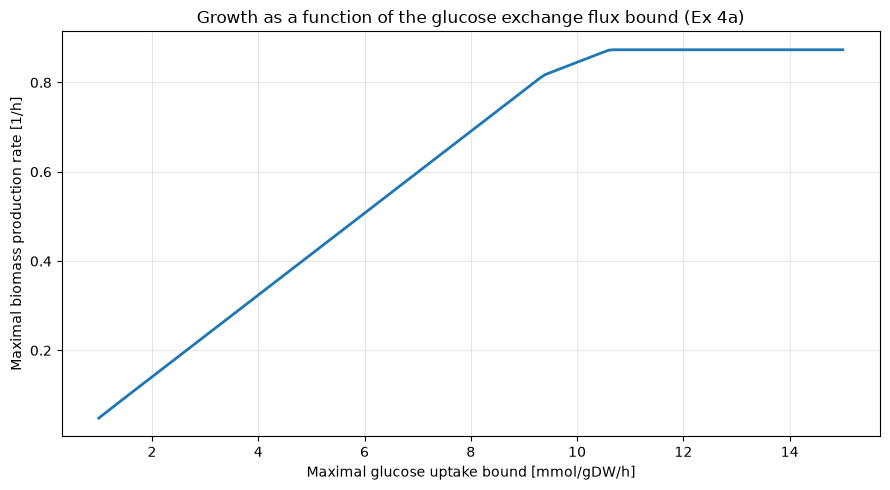

Computed 141 points from glucose = 1.0 to 15.0.


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# sweeping the maximal glucose-uptake bound over [1, 15] in steps 0f 0,1
GLUCOSE_MAX    = 15
N_POINTS       = int(round((GLUCOSE_MAX - 1) / 0.1)) + 1
glucose_limits = np.linspace(1, GLUCOSE_MAX, N_POINTS)
biomasses      = []

for glc in glucose_limits:
    model.reactions.EX_glc__D_e.lower_bound = -glc     # uptake direction: negative flux
    sol = model.optimize()
    biomasses.append(sol.objective_value)

plt.figure(figsize=(9, 5))
plt.plot(glucose_limits, biomasses, lw=2)
plt.xlabel('Maximal glucose uptake bound [mmol/gDW/h]')
plt.ylabel('Maximal biomass production rate [1/h]')
plt.title('Growth as a function of the glucose exchange flux bound (Ex 4a)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Computed {len(biomasses)} points from glucose = {glucose_limits[0]:.1f} to '
      f'{glucose_limits[-1]:.1f}.')

The plot shows the full relationship between substrate availability and maximal growth, including
the three distinct segments of the curve that are analysed further in Exercises 4b/c.
